# Group Exercise E2: Michaelis-Menten Kinetics in PFR & CSTR
**Course 28342: Reaktionsteknik**

*Week 2 Exercise 2*

This notebook explores the performance of Plug Flow Reactors (PFR) and Continuous Stirred-Tank Reactors (CSTR) for enzyme-type reactions.

## Reference Materials
*   Exercise Description: **"Grupperegningsopgave E2.pdf"**[cite: 3]
*   Official Solutions: **"Losning Opgave E2.pdf"**[cite: 4]

## Reaction Parameters
The reaction $A \rightarrow products$ follows Michaelis-Menten kinetics[cite: 3]:
$$-r_A = \frac{kC_A}{1+KC_A}$$

*   $k = 0.001 \text{ s}^{-1}$[cite: 3]
*   $K = 1.0 \text{ m}^3/\text{mol}$[cite: 3]
*   $C_{A0} = 1.0 \text{ mol/m}^3$[cite: 3]

---
## Problem A: Plug Flow Reactor (PFR)
For a constant density PFR, the design equation relates space time $\tau$ to concentration[cite: 4]:
$$\tau = \frac{1}{k}\ln\left(\frac{C_{A0}}{C_A}\right) + \frac{K}{k}(C_{A0} - C_A)$$

In [ ]:
import numpy as np
from scipy.optimize import fsolve

# Constants from "Grupperegningsopgave E2.pdf"[cite: 3]
k = 0.001
K = 1.0
CA0 = 1.0

# A2: Compute tau for CA = 0.1 mol/m^3[cite: 3]
CA_target = 0.1
tau_pfr_01 = (1/k) * np.log(CA0/CA_target) + (K/k) * (CA0 - CA_target)

# A3: Compute CA for specific tau values (Requires iteration/root finding)[cite: 3]
def pfr_residue(CA, tau):
    # Rearranged design equation to solve for zero[cite: 4]
    return (1/k) * np.log(CA0/CA) + (K/k) * (CA0 - CA) - tau

tau_1000 = 1000
tau_3000 = 3000

ca_pfr_1000 = fsolve(pfr_residue, 0.5, args=(tau_1000))[0]
ca_pfr_3000 = fsolve(pfr_residue, 0.1, args=(tau_3000))[0]

print(f"--- PFR Results ---")
print(f"Residence time for CA=0.1: {tau_pfr_01:.1f} s") # Expected: 3203s[cite: 4]
print(f"CA at tau=1000s: {ca_pfr_1000:.4f} mol/m^3") # Expected: 0.5671[cite: 4]
print(f"CA at tau=3000s: {ca_pfr_3000:.4f} mol/m^3") # Expected: 0.1200[cite: 4]

--- PFR Results ---
Residence time for CA=0.1: 3202.6 s
CA at tau=1000s: 0.5671 mol/m^3
CA at tau=3000s: 0.1200 mol/m^3


---
## Problem B: Continuous Stirred-Tank Reactor (CSTR)
For a CSTR, the design equation is algebraic[cite: 4]:
$$\tau = \frac{C_{A0} - C_A}{-r_A} = \frac{(C_{A0} - C_A)(1 + KC_A)}{kC_A}$$

This can be rearranged into a quadratic form to solve for $C_A$ explicitly[cite: 4]:
$$KC_A^2 + (1 + k\tau - KC_{A0})C_A - C_{A0} = 0$$

In [ ]:
# B2: Compute tau for CA = 0.1 mol/m^3[cite: 3]
tau_cstr_01 = ((CA0 - CA_target) * (1 + K * CA_target)) / (k * CA_target)

# B3: Compute CA for specific tau values[cite: 3]
def solve_cstr_ca(tau):
    # Using the quadratic solution provided in "Losning Opgave E2.pdf"[cite: 4]
    # For these parameters, it simplifies to: CA^2 + k*tau*CA - 1 = 0
    return (-k*tau + np.sqrt((k*tau)**2 + 4)) / 2

ca_cstr_1000 = solve_cstr_ca(tau_1000)
ca_cstr_3000 = solve_cstr_ca(tau_3000)

print(f"--- CSTR Results ---")
print(f"Residence time for CA=0.1: {tau_cstr_01:.1f} s") # Expected: 9900s[cite: 4]
print(f"CA at tau=1000s: {ca_cstr_1000:.4f} mol/m^3") # Expected: 0.6180[cite: 4]
print(f"CA at tau=3000s: {ca_cstr_3000:.4f} mol/m^3") # Expected: 0.3028[cite: 4]

--- CSTR Results ---
Residence time for CA=0.1: 9900.0 s
CA at tau=1000s: 0.6180 mol/m^3
CA at tau=3000s: 0.3028 mol/m^3


---
## Problem C: Visual Comparison
The PFR is generally more efficient than the CSTR for this kinetics because the CSTR operates entirely at the exit concentration (the lowest concentration in the system), which results in a lower reaction rate[cite: 4].

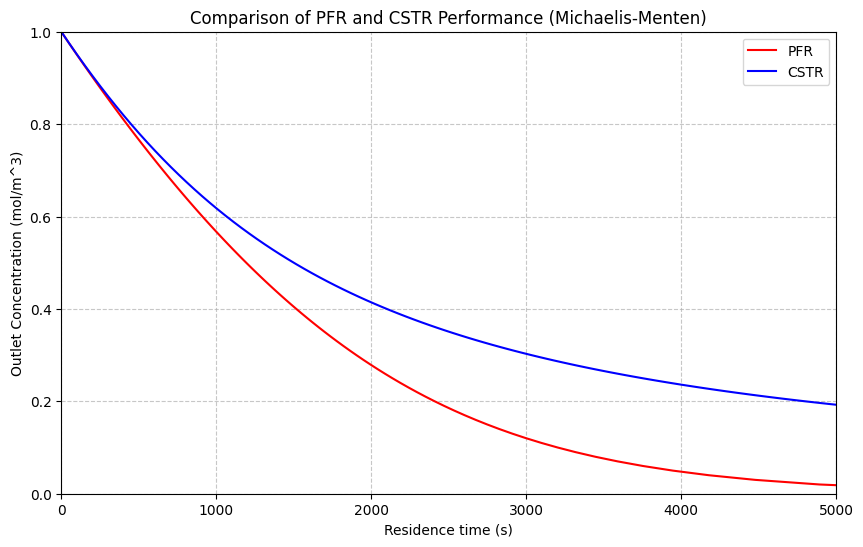

In [ ]:
import matplotlib.pyplot as plt

# Instead of solving for CA at a fixed tau, we calculate tau for a range of CA.
# This avoids numerical instability in the PFR logarithmic term.
ca_range = np.linspace(0.01, 1.0, 100) # Concentration from 0.01 to 1.0[cite: 3]

# Calculate PFR tau for each CA using the analytical solution
# tau = (1/k)*ln(CA0/CA) + (K/k)*(CA0 - CA)
pfr_tau_vals = (1/k) * np.log(CA0/ca_range) + (K/k) * (CA0 - ca_range)

# Calculate CSTR CA for a matching range of tau values
tau_plot_range = np.linspace(0, 5000, 100)
cstr_plot_ca = [solve_cstr_ca(t) for t in tau_plot_range]

plt.figure(figsize=(10, 6))

# Plot PFR: Note we plot pfr_tau_vals on X and ca_range on Y
plt.plot(pfr_tau_vals, ca_range, 'r-', label='PFR')

# Plot CSTR
plt.plot(tau_plot_range, cstr_plot_ca, 'b-', label='CSTR')

plt.xlim(0, 5000) # Limit x-axis to 5000s as per the exercise
plt.ylim(0, 1.0)
plt.xlabel('Residence time (s)')
plt.ylabel('Outlet Concentration (mol/m^3)')
plt.title('Comparison of PFR and CSTR Performance (Michaelis-Menten)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()